In [ ]:
# Check embedding data from extract_iemocap_embeddings.py

import numpy as np

# Path to the exported .npy embeddings file
FILE_PATH = r"d:\Resfes\Project\Ser\data\Embeddings\iemocap_static_embeddings_step1.npy"

print("[INFO] Loading acoustic embeddings...")
# Load the .npy file. The 'allow_pickle=True' argument is mandatory for loading a serialized Dictionary
data = np.load(FILE_PATH, allow_pickle=True).item()

# 1. Verify the total number of extracted samples (Expected: ~10,039 utterances for IEMOCAP)
total_samples = len(data)
print(f"[VERIFICATION 1] Total extracted utterances: {total_samples}")

# 2. Inspect the dictionary key format (Expected: Standard IEMOCAP Utterance IDs)
sample_keys = list(data.keys())
print(f"[VERIFICATION 2] First sample Key (ID): {sample_keys[0]}")
print(f"                 Last sample Key (ID):  {sample_keys[-1]}")

# 3. Validate the dimensions and data type of the embedding vector (Expected Shape: (768,))
sample_vector = data[sample_keys[0]]
print(f"[VERIFICATION 3] Embedding Vector Shape: {sample_vector.shape}")
print(f"[VERIFICATION 4] Embedding Data Type:    {sample_vector.dtype}")

# 4. Check for any corrupted, invalid, or NaN (Not a Number) values within the matrix
has_nan = np.isnan(sample_vector).any()
print(f"[VERIFICATION 5] Contains corrupted/NaN values?: {'⚠️ YES (Data Corrupted)' if has_nan else 'No, data is clean'}")

[INFO] Loading acoustic embeddings...
[VERIFICATION 1] Total extracted utterances: 10039
[VERIFICATION 2] First sample Key (ID): Ses01F_impro01_F000
                 Last sample Key (ID):  Ses05M_script03_2_M045
[VERIFICATION 3] Embedding Vector Shape: (768,)
[VERIFICATION 4] Embedding Data Type:    float32
[VERIFICATION 5] Contains corrupted/NaN values?: No, data is clean


In [2]:
import sys
import os
import torch
from torch.utils.data import DataLoader

# Add the 'Ser' root directory to the system path so Python can import from the 'src' folder
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Import the custom module you created
from src.data.iemocap_loader import IEMOCAPConversationalDataset

# Path configuration
EMBEDDINGS_PATH = r"d:\Resfes\Project\Ser\data\Embeddings\iemocap_static_embeddings_step1.npy"
METADATA_CSV_PATH = r"d:\Resfes\Project\Ser\data\DataFrames\iemocap_metadata.csv"

In [3]:
print("\n--- INITIALIZING DATASET (STAGE 1: COARSE SENTIMENT) ---")
dataset_stage1 = IEMOCAPConversationalDataset(METADATA_CSV_PATH, EMBEDDINGS_PATH, target_stage=1)

print("\n--- INITIALIZING DATALOADER ---")
dataloader = DataLoader(dataset_stage1, batch_size=32, shuffle=True)

# Extract the first batch to verify matrix structure
X_batch, y_batch = next(iter(dataloader))

print("\n--- SANITY CHECK RESULTS ---")
print(f"X_batch Shape  : {X_batch.shape} --> Expected: [32, 3, 768]")
print(f"y_batch Shape  : {y_batch.shape}      --> Expected: [32]")
print(f"Sample Labels  : {y_batch[:10].tolist()}")


--- INITIALIZING DATASET (STAGE 1: COARSE SENTIMENT) ---
[INFO] Loading 768-D acoustic embeddings into memory...
[INFO] Loading and sorting metadata...
[INFO] Applying sliding window mechanism (N=3) across dialogues...
[SUCCESS] Generated 10039 sequence windows.

--- INITIALIZING DATALOADER ---

--- SANITY CHECK RESULTS ---
X_batch Shape  : torch.Size([32, 3, 768]) --> Expected: [32, 3, 768]
y_batch Shape  : torch.Size([32])      --> Expected: [32]
Sample Labels  : [-1, -1, 0, 2, -1, 0, 0, 2, 0, 0]


In [4]:
# Print the first 5 system sequences to verify that Zero-Padding is functioning correctly
print("\n--- VISUALIZING FIRST 5 SEQUENCES (IDs) ---")
for i in range(5):
    print(f"Sequence {i}: {dataset_stage1.sequences[i]} | Target Label: {dataset_stage1.targets_s1[i]}")


--- VISUALIZING FIRST 5 SEQUENCES (IDs) ---
Sequence 0: [None, None, 'Ses01F_impro01_F000'] | Target Label: 1
Sequence 1: [None, 'Ses01F_impro01_F000', 'Ses01F_impro01_M000'] | Target Label: 0
Sequence 2: ['Ses01F_impro01_F000', 'Ses01F_impro01_M000', 'Ses01F_impro01_F001'] | Target Label: 1
Sequence 3: ['Ses01F_impro01_M000', 'Ses01F_impro01_F001', 'Ses01F_impro01_M001'] | Target Label: 0
Sequence 4: ['Ses01F_impro01_F001', 'Ses01F_impro01_M001', 'Ses01F_impro01_F002'] | Target Label: 1


[STATS] Total unique dialogues: 151
[STATS] Average turns per dialogue: 66.48
[STATS] Median turns per dialogue:  67.00
[STATS] Max turns: 167 | Min turns: 24


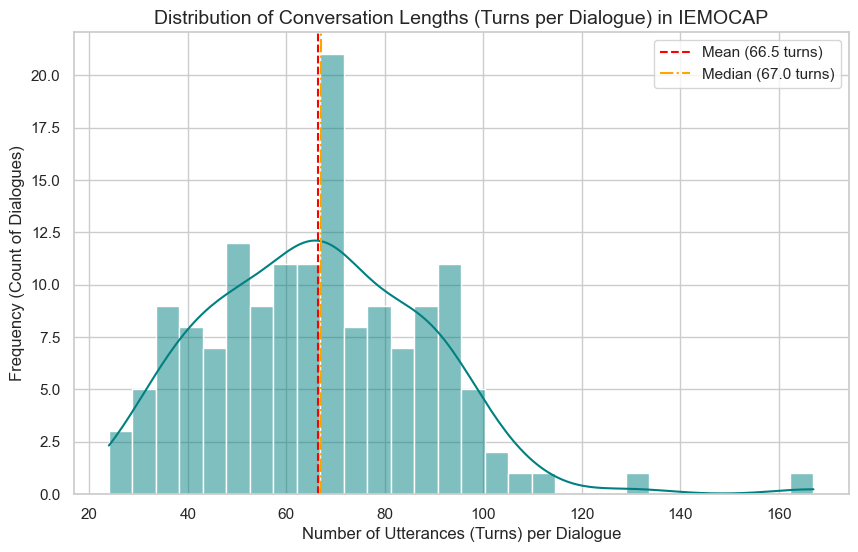

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Read metadata and count the number of turns per unique Dialogue ID
df = pd.read_csv(METADATA_CSV_PATH)
dialogue_lengths = df.groupby("Dialog_ID").size()

# 2. Calculate key statistical metrics
mean_len = dialogue_lengths.mean()
median_len = dialogue_lengths.median()
max_len = dialogue_lengths.max()
min_len = dialogue_lengths.min()

print(f"[STATS] Total unique dialogues: {len(dialogue_lengths)}")
print(f"[STATS] Average turns per dialogue: {mean_len:.2f}")
print(f"[STATS] Median turns per dialogue:  {median_len:.2f}")
print(f"[STATS] Max turns: {max_len} | Min turns: {min_len}")

# 3. Plot the distribution histogram
sns.histplot(dialogue_lengths, bins=30, kde=True, color="teal")
plt.axvline(mean_len, color="red", linestyle="--", label=f"Mean ({mean_len:.1f} turns)")
plt.axvline(median_len, color="orange", linestyle="-.", label=f"Median ({median_len:.1f} turns)")

plt.title("Distribution of Conversation Lengths (Turns per Dialogue) in IEMOCAP", fontsize=14)
plt.xlabel("Number of Utterances (Turns) per Dialogue", fontsize=12)
plt.ylabel("Frequency (Count of Dialogues)", fontsize=12)
plt.legend(fontsize=11)
plt.show()

[INFO] Matrix shape before dim-reduction: (7380, 768)
[INFO] Executing PCA reduction...
[INFO] Executing t-SNE non-linear projection (this may take a minute)...


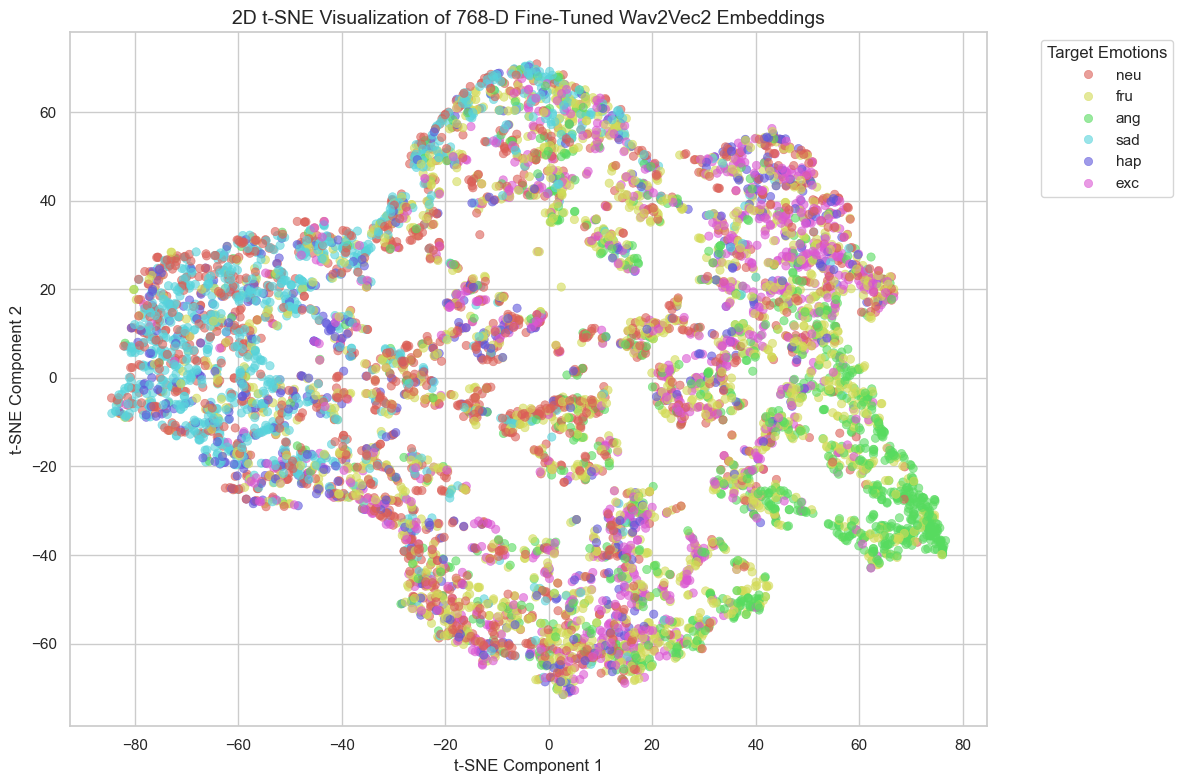

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Load acoustic embeddings store
embeddings_dict = np.load(EMBEDDINGS_PATH, allow_pickle=True).item()
df_meta = pd.read_csv(METADATA_CSV_PATH)

# 2. Align metadata rows with available keys in the embeddings dictionary
valid_data = []
labels = []

for _, row in df_meta.iterrows():
    utt_id = row["Utterance_ID"]
    raw_emo = row["Raw_Emotion"]
    
    # Filter out undefined/garbage tokens (e.g., 'xxx') to keep the plot clean
    if utt_id in embeddings_dict and raw_emo in ['neu', 'ang', 'sad', 'fru', 'hap', 'exc']:
        valid_data.append(embeddings_dict[utt_id])
        labels.append(raw_emo)

X_features = np.array(valid_data) # Matrix shape: (N_samples, 768)
y_labels = np.array(labels)

print(f"[INFO] Matrix shape before dim-reduction: {X_features.shape}")

# 3. Step A: Apply PCA to compress from 768-D down to 50-D (Speeds up t-SNE significantly)
print("[INFO] Executing PCA reduction...")
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_features)

# 4. Step B: Apply t-SNE to compress from 50-D down to 2-D coordinates
print("[INFO] Executing t-SNE non-linear projection (this may take a minute)...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# 5. Construct a temporary DataFrame for plotting via Seaborn
df_plot = pd.DataFrame({
    "t-SNE Dimension 1": X_tsne[:, 0],
    "t-SNE Dimension 2": X_tsne[:, 1],
    "Emotion": y_labels
})

# 6. Plot the scatter graph with a distinct color palette
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="t-SNE Dimension 1", y="t-SNE Dimension 2",
    hue="Emotion",
    palette="hls",
    data=df_plot,
    alpha=0.6,
    edgecolor=None
)

plt.title("2D t-SNE Visualization of 768-D Fine-Tuned Wav2Vec2 Embeddings", fontsize=14)
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)
plt.legend(title="Target Emotions", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

[INFO] Loading 768-D acoustic embeddings into memory...
[INFO] Loading and sorting metadata...
[INFO] Applying sliding window mechanism (N=3) across dialogues...
[SUCCESS] Generated 10039 sequence windows.
[INFO] Generating predictions from saved .pth checkpoints...


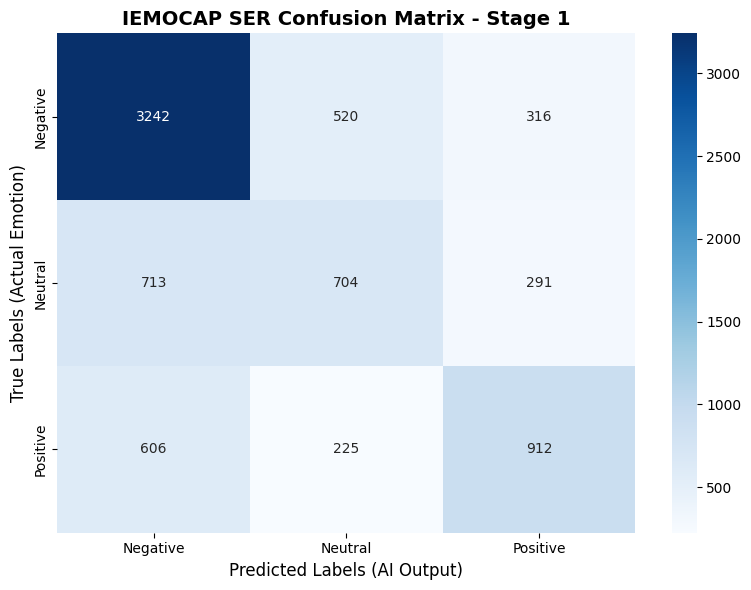

              precision    recall  f1-score   support

    Negative       0.71      0.79      0.75      4078
     Neutral       0.49      0.41      0.45      1708
    Positive       0.60      0.52      0.56      1743

    accuracy                           0.65      7529
   macro avg       0.60      0.58      0.59      7529
weighted avg       0.63      0.65      0.64      7529



In [1]:
import os
import sys
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Setup project roots
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.data.iemocap_loader import IEMOCAPConversationalDataset
from src.models.bigru_stage3 import ConversationalBiGRU

# Configurations
EMBEDDINGS_PATH = os.path.join(PROJECT_ROOT, "data", "Embeddings", "iemocap_static_embeddings_step1.npy")
METADATA_CSV_PATH = os.path.join(PROJECT_ROOT, "data", "DataFrames", "iemocap_metadata.csv")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints", "stage3_bigru")
TARGET_STAGE = 1
NUM_CLASSES = 3 if TARGET_STAGE == 1 else 5
class_names = ['Negative', 'Neutral', 'Positive'] if TARGET_STAGE == 1 else ['Anger', 'Sadness', 'Fear', 'Disgust', 'Frustration']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Dataset
dataset = IEMOCAPConversationalDataset(METADATA_CSV_PATH, EMBEDDINGS_PATH, target_stage=TARGET_STAGE)

# Helper function copied from your training script
def get_loso_indices(dataset, test_session):
    train_indices, test_indices = [], []
    for idx, seq in enumerate(dataset.sequences):
        current_utt_id = seq[-1]
        session_id = int(current_utt_id.split('_')[0][3:5])
        if session_id == test_session: test_indices.append(idx)
        else: train_indices.append(idx)
    return train_indices, test_indices

all_preds = []
all_targets = []

# 2. Reconstruct out-of-fold predictions using saved .pth checkpoints
print("[INFO] Generating predictions from saved .pth checkpoints...")
for test_session in range(1, 6):
    _, test_idx = get_loso_indices(dataset, test_session)
    test_subset = Subset(dataset, test_idx)
    test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)
    
    # Initialize fresh model structure and map saved weights onto it
    model = ConversationalBiGRU(num_classes=NUM_CLASSES).to(device)
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"stage_{TARGET_STAGE}_best_model_fold_{test_session}.pth")
    
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval() # Vital: Enforces deterministic evaluation mode
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.append(preds.cpu())
            all_targets.append(batch_y.cpu())

# Flatten list of tensors into unified arrays
true_labels = torch.cat(all_targets).numpy()
pred_labels = torch.cat(all_preds).numpy()

# Mask out -1 unknown tokens so your matrix only evaluates real data
valid_indices = true_labels != -1
true_labels = true_labels[valid_indices]
pred_labels = pred_labels[valid_indices]

# 3. Plot Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'IEMOCAP SER Confusion Matrix - Stage {TARGET_STAGE}', fontsize=14, fontweight='bold')
plt.ylabel('True Labels (Actual Emotion)', fontsize=12)
plt.xlabel('Predicted Labels (AI Output)', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Print Report
print(classification_report(true_labels, pred_labels, target_names=class_names))